<a href="https://colab.research.google.com/github/Alfredosernas/Machine-Learning/blob/main/hans_on4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

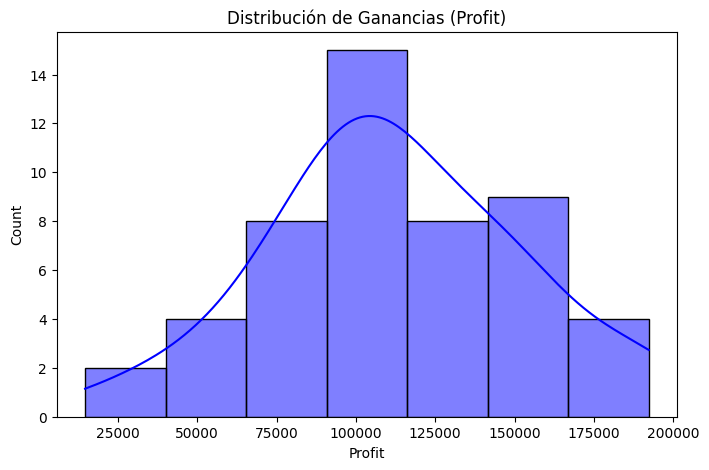

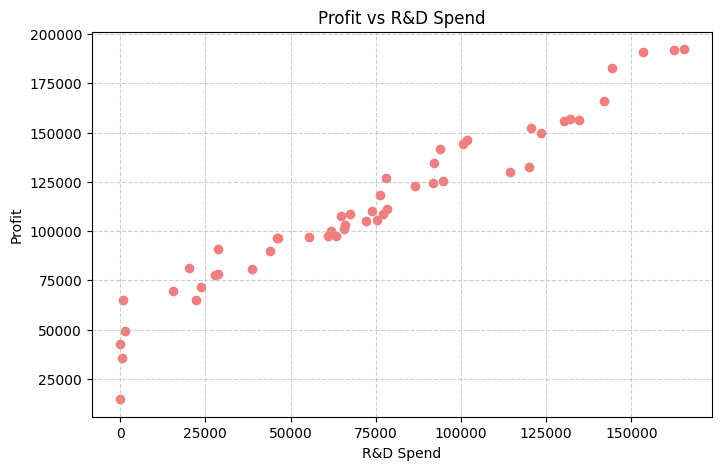

--- Comparación: [Predicción | Valor Real] ---
[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]

Intercepto: 42554.17
Coeficientes: [-9.59e+02  6.99e+02  7.73e-01  3.29e-02  3.66e-02]


In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score # Para medir la precisión

# 2. Get dataset
df_start = pd.read_csv('/content/50_Startups.csv')

# 3. Data distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_start['Profit'], kde=True, color='blue')
plt.title('Distribución de Ganancias (Profit)')
plt.show()

# 4. Relationship between Profit and R&D Spend
plt.figure(figsize=(8, 5))
plt.scatter(df_start['R&D Spend'], df_start['Profit'], color = 'lightcoral')
plt.title('Profit vs R&D Spend')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Split dataset in dependent/independent variables
X = df_start.iloc[:, :-1].values
y = df_start.iloc[:, -1].values

# 6. One-hot encoding of categorical data
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [3])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))

# Evitar la trampa de la variable ficticia (Eliminar una columna de las categorías)
X = X[:, 1:]

# 7. Splitting dataset into test/train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# 8. Regressor model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# 9. Predict result
y_pred = regressor.predict(X_test)

# 10. Compare predicted result with actual value
np.set_printoptions(precision = 2)
print("--- Comparación: [Predicción | Valor Real] ---")
result = np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1)
print(result)

# 11. Regressor coefficients and Accuracy
print("\n" + "="*30)
print(f'Intercepto: {regressor.intercept_:.2f}')
print(f'Coeficientes: {regressor.coef_}')
print("="*30)